# Figure 2
## Width selection
### Author: Martin Loza
### Date: 25/12/08

We would like to explore the density of PCG around ncRNA's TSS. 
We would like to generate plots that allows us to define thresholds for downstream analyses

In [66]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
    # library(svglite)
})

# Local variables 
seed = 777
date = "251208"

red = "#E41A1C"
blue = "#377EB8"
text_size = 18
width = 18.6
dot_size = 4
line_size = 1.5
dpi = 300

in_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Data/ENSEMBL/distances/single_pcg_gene_transcripts/"
out_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/Figure_2/Plots/"

# Local Functions

# Simplified function to calculate density metrics for a given window size
calculate_density_metrics <- function(data, window_size, distance_column = "abs_strand_distance") {
    # Filter data within the window
    filtered_data <- data %>%
        filter(!!sym(distance_column) <= window_size)
    
    # Calculate counts and density
    metrics <- filtered_data %>%
        group_by(ncrna_strand) %>%
        summarise(count = n(), .groups = 'drop') %>%
        mutate(
            window_size = window_size,
            strand = ifelse(ncrna_strand == 1, "Forward", "Reverse"),
            density = count / window_size
        )
    
    return(metrics)
}

### Load and setup the data

In [2]:
# Load the setup transcripts data
# We have different species, so let's create a list to store the data
data_list = list()

# Search for the available files
files <- list.files(in_dir)

# Load the data for each species
for (file in files) {
    # Remove the underscore and everything after it to get the species names
    species_name <- str_replace(file, "_.*", "")
    data_list[[species_name]] <- read.table(file.path(in_dir, file), sep = "\t", header = TRUE, 
                                            stringsAsFactors = FALSE, quote = "", 
                                            comment.char = "", fill = TRUE, row.names = NULL)
}

head(data_list[["dog"]], 3)


,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>
1,1,ENSCAFT00845000004,41931353,,1,lncRNA,ENSCAFT00845037491,AKAP12,41882972,-48381,-48381
2,1,ENSCAFT00845000004,41931353,,1,lncRNA,ENSCAFT00845000019,ARMT1,41984839,53486,53486
3,1,ENSCAFT00845000004,41931353,,1,lncRNA,ENSCAFT00845000026,CCDC170,42020714,89361,89361


In [3]:
names(data_list)

[1] "armadillo"  "chicken"    "dog"        "drosophila" "elegans"   
 [6] "ferret"     "human"      "macaque"    "mouse"      "rat"       
[11] "zebrafish"

In [4]:
# Let's place an order in the plots
ordered_species <- c("human", "mouse", "macaque", 
                     "rat", "zebrafish", "ferret", 
                     "dog", "chicken", "armadillo", 
                     "drosophila", "elegans")

# Arrange the data_list according to the ordered_species
data_list <- data_list[ordered_species]

### Selection of the thresholds

Let's try to analyse the density of PCG around ncRNA's TSS with different width thresholds.

In this case, let's get and absolute distance to avoid any effects from upstream and downstream location

In [5]:
# Add absolute distance column
for (species in names(data_list)) {
    data_list[[species]] <- data_list[[species]] %>%
        mutate(abs_strand_distance = abs(strand_distance))
}

In [84]:
# Define the window sizes to compare (in bp)
window_sizes <- c(1000, 5000, 10000, 50000, 100000, 500000, 1000000)

In [92]:
# Calculate density metrics for all window sizes and all species
all_density_metrics <- list()

for (species in names(data_list)) {
    species_metrics <- data.frame()
    
    for (ws in window_sizes) {
        temp_metrics <- calculate_density_metrics(data_list[[species]], window_size = ws)
        species_metrics <- rbind(species_metrics, temp_metrics)
    }
    
    species_metrics$species <- species
    all_density_metrics[[species]] <- species_metrics
}

# Combine all metrics into a single dataframe
density_df <- do.call(rbind, all_density_metrics)
rownames(density_df) <- NULL

head(density_df, 10)

ncrna_strand,count,window_size,strand,density,species
<int>,<int>,<dbl>,<chr>,<dbl>,<chr>
-1,18778,1e+03,Reverse,18.77800,human
1,18671,1e+03,Forward,18.67100,human
-1,26064,5e+03,Reverse,5.21280,human
1,25446,5e+03,Forward,5.08920,human
-1,33453,1e+04,Reverse,3.34530,human
1,32939,1e+04,Forward,3.29390,human
-1,104550,5e+04,Reverse,2.09100,human
1,103002,5e+04,Forward,2.06004,human
-1,196798,1e+05,Reverse,1.96798,human


In [93]:
# Visualize density (count per bp) across window sizes
options(repr.plot.width=12, repr.plot.height=9)


p_density <- density_df %>%
    ggplot(aes(x = window_size / 1000, y = density, color = strand, group = strand)) +
    geom_line(linewidth = line_size, alpha = 0.5) +
    geom_point(size = dot_size, alpha = 0.5) +
    facet_wrap(~str_to_title(species), scales = "free_y",ncol = 3) +
    scale_color_manual(values = c("Forward" = blue, "Reverse" = red)) +
    scale_x_log10(breaks = window_sizes / 1000, 
                  labels = c("1kb", "5kb", "10kb", "50kb", "100kb", "500kb", "1Mb")) +
    theme_minimal() +
    labs(x = "Window size (log scale)",
         y = "Density (PCG / window size)",
         color = "ncRNA strand") +
    theme(text = element_text(size = text_size),
          strip.text = element_text(size = text_size + 1),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "bottom",
        #   panel.background = element_rect(fill = "white"),
        #   plot.background = element_rect(fill = "white")
          ) +
    guides(color = guide_legend(override.aes = list(alpha = 1)))

# p_density

In [94]:
# Save the figure as PDF
ggsave(filename = file.path(out_dir, paste0("Sup_Fig_ncRNA_PCG_density_vs_window_size_", date, ".pdf")),
    plot = p_density, 
    width = width, height = width * 0.75, units = "in", dpi = dpi)

### lncRNA

For Human and mouse, let's produce a similar plot only for lncRNA

In [68]:
selected_species <- c("human", "mouse")
# Select species
selected_data_species <- data_list[selected_species]
# Select only lncRNA related data
for (species in names(selected_data_species)) {
    selected_data_species[[species]] <- selected_data_species[[species]] %>%
        filter(gene_biotype == "lncRNA")
}

Get the metrics

In [85]:
# Define the window sizes to compare (in bp)
# window_sizes <- seq(1000, 100000, by = 5000)
# window_size <- c(window_sizes, 500000, 1000000)
# Calculate density metrics for all window sizes and all species
selected_species_densities <- list()

for (species in names(selected_data_species)) {
    species_metrics <- data.frame()
    
    for (ws in window_sizes) {
        temp_metrics <- calculate_density_metrics(selected_data_species[[species]], window_size = ws)
        species_metrics <- rbind(species_metrics, temp_metrics)
    }
    
    species_metrics$species <- species
    selected_species_densities[[species]] <- species_metrics
}

# Combine all metrics into a single dataframe
density_df <- do.call(rbind, selected_species_densities)
rownames(density_df) <- NULL

head(density_df, 10)

ncrna_strand,count,window_size,strand,density,species
<int>,<int>,<dbl>,<chr>,<dbl>,<chr>
-1,18527,1e+03,Reverse,18.52700,human
1,18331,1e+03,Forward,18.33100,human
-1,25077,5e+03,Reverse,5.01540,human
1,24252,5e+03,Forward,4.85040,human
-1,31690,1e+04,Reverse,3.16900,human
1,30906,1e+04,Forward,3.09060,human
-1,98315,5e+04,Reverse,1.96630,human
1,96590,5e+04,Forward,1.93180,human
-1,185800,1e+05,Reverse,1.85800,human


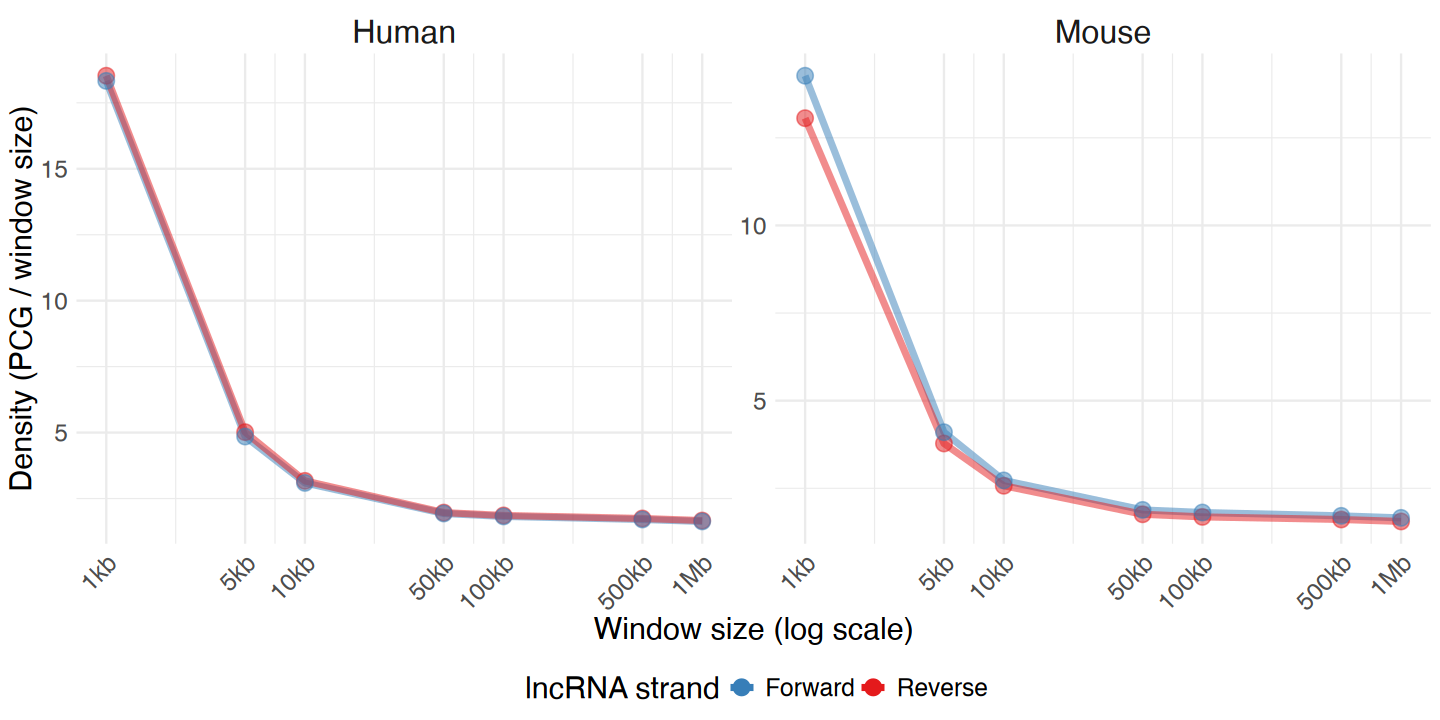

In [90]:
# Visualize density (count per bp) across window sizes
options(repr.plot.width=12, repr.plot.height=6)

p_density <- density_df %>%
    ggplot(aes(x = window_size / 1000, y = density, color = strand, group = strand)) +
    geom_line(linewidth = line_size, alpha = 0.5) +
    geom_point(size = dot_size, alpha = 0.5) +
    facet_wrap(~str_to_title(species), scales = "free_y",ncol = 3) +
    scale_color_manual(values = c("Forward" = blue, "Reverse" = red)) +
    scale_x_log10(breaks = window_sizes / 1000, 
                  labels = c("1kb", "5kb", "10kb", "50kb", "100kb", "500kb", "1Mb")) +
    theme_minimal() +
    labs(x = "Window size (log scale)",
         y = "Density (PCG / window size)",
         color = "lncRNA strand") +
    theme(text = element_text(size = text_size),
          strip.text = element_text(size = text_size + 1),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "bottom",
        #   panel.background = element_rect(fill = "white"),
        #   plot.background = element_rect(fill = "white")
          ) +
    guides(color = guide_legend(override.aes = list(alpha = 1)))

p_density

In [91]:
# Save the figure as PDF
ggsave(filename = file.path(out_dir, paste0("Sup_Fig_lncRNA_PCG_density_vs_window_size_", date, ".pdf")),
    plot = p_density, 
    width = (width/3)*2, height = width * 0.75/3, units = "in", dpi = dpi)